In [1]:
import pandas as pd

In [3]:
data = pd.read_csv('/content/data shift hospital dataset.zip')

In [ ]:
data.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
print(data.shape)
print(data.head())
print(data.info())
print(data.isnull().sum())

(303, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    i

In [5]:
hospital_A = data[data['age'] < 50].copy()            #Creating hospital based on age(50)
hospital_B = data[data['age'] >= 50].copy()

print("Hospital A size:", hospital_A.shape)
print("Hospital B size:", hospital_B.shape)

Hospital A size: (88, 14)
Hospital B size: (215, 14)


In [6]:
X_A = hospital_A.drop('target', axis=1)               #seperates input and output variables
y_A = hospital_A['target']

X_B = hospital_B.drop('target', axis=1)
y_B = hospital_B['target']


In [7]:
from sklearn.linear_model import LogisticRegression   #accuracy of hospital A without FL integration
from sklearn.metrics import accuracy_score, roc_auc_score

model = LogisticRegression(max_iter=1000)
model.fit(X_A, y_A)

# Evaluate on Hospital A
y_pred_A = model.predict(X_A)
print("Accuracy on Hospital A:", accuracy_score(y_A, y_pred_A))

Accuracy on Hospital A: 0.9204545454545454


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [8]:
y_pred_B = model.predict(X_B)                        ##accuracy of hospital B without FL integration
print("Accuracy on Hospital B:", accuracy_score(y_B, y_pred_B))

print("AUC on Hospital B:",
      roc_auc_score(y_B, model.predict_proba(X_B)[:,1]))

Accuracy on Hospital B: 0.7581395348837209
AUC on Hospital B: 0.871879334257975


In [9]:
from sklearn.model_selection import train_test_split

X_adapt, _, y_adapt, _ = train_test_split(
    X_B, y_B,
    train_size=50,
    stratify=y_B,
    random_state=42                  #taking 50 samples from Hospital B for fine tuning and self adaption
)

In [10]:
hospital_A = data[data['age'] < 50].copy()    #filtering based on AGE
hospital_B = data[data['age'] >= 50].copy()

In [11]:
X_A = hospital_A.drop('target', axis=1)        #seperates input and output variables
y_A = hospital_A['target']

X_B = hospital_B.drop('target', axis=1)
y_B = hospital_B['target']

In [12]:
from sklearn.linear_model import LogisticRegression #This creates a function that trains a logistic regression model on any given hospital’s data.
import numpy as np

def train_local_model(X, y):
    model = LogisticRegression(max_iter=1000)
    model.fit(X, y)
    return model

In [13]:
model_A = train_local_model(X_A, y_A)  #This trains two completely separate models , starting of FL
model_B = train_local_model(X_B, y_B)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
#Instead of sharing patient data, hospitals share model weights , implementation of FL
# Average coefficients
global_coef = (model_A.coef_ + model_B.coef_) / 2
global_intercept = (model_A.intercept_ + model_B.intercept_) / 2

# Create global model
global_model = LogisticRegression(max_iter=1000)
global_model.coef_ = global_coef
global_model.intercept_ = global_intercept
global_model.classes_ = model_A.classes_

In [15]:
#accuracy of A nd B using FL
from sklearn.metrics import accuracy_score, roc_auc_score

# Evaluate on Hospital A
y_pred_A = global_model.predict(X_A)
acc_A = accuracy_score(y_A, y_pred_A)

# Evaluate on Hospital B
y_pred_B = global_model.predict(X_B)
acc_B = accuracy_score(y_B, y_pred_B)

print("Federated Accuracy on Hospital A:", acc_A)
print("Federated Accuracy on Hospital B:", acc_B)

Federated Accuracy on Hospital A: 0.8977272727272727
Federated Accuracy on Hospital B: 0.8232558139534883


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [16]:
##accuracy of B using  without FL
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

single_model = LogisticRegression(max_iter=1000)
single_model.fit(X_A, y_A)

drop_pred = single_model.predict(X_B)
drop_acc = accuracy_score(y_B, drop_pred)

print("Single Hospital Model on B:", drop_acc)

Single Hospital Model on B: 0.7581395348837209


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [17]:
#comparing accuracy with and without using FL , using FL gives more accuracy!
y_pred_B = global_model.predict(X_B)
acc_B = accuracy_score(y_B, y_pred_B)

print("Federated Model on B:", acc_B)

Federated Model on B: 0.8232558139534883


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


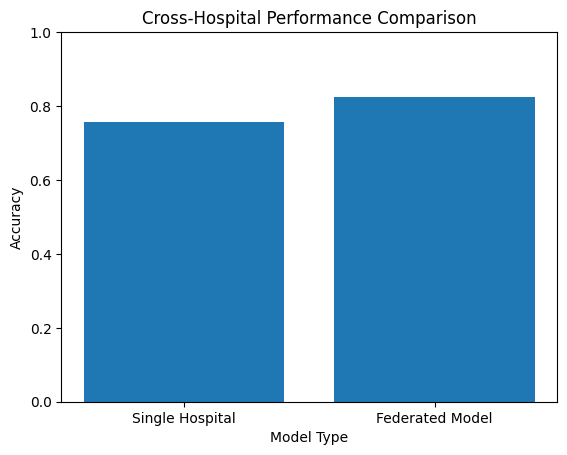

In [18]:
import matplotlib.pyplot as plt

models = ['Single Hospital', 'Federated Model']
accuracies = [drop_acc, acc_B]

plt.figure()
plt.bar(models, accuracies)
plt.xlabel("Model Type")
plt.ylabel("Accuracy")
plt.title("Cross-Hospital Performance Comparison")
plt.ylim(0, 1)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


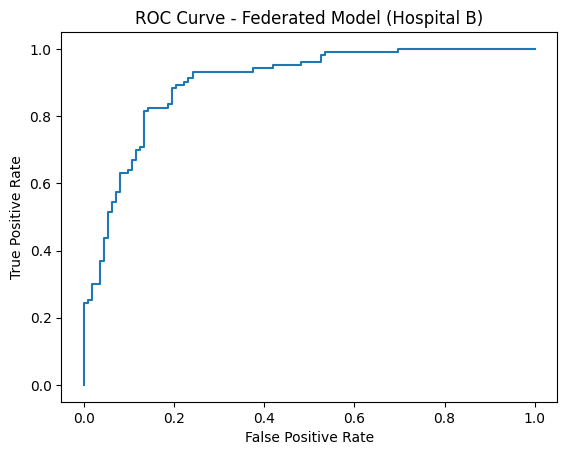

In [19]:
from sklearn.metrics import roc_curve

# ROC for federated model
y_probs = global_model.predict_proba(X_B)[:,1]
fpr, tpr, _ = roc_curve(y_B, y_probs)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Federated Model (Hospital B)")
plt.show()

In [20]:
from sklearn.metrics import roc_auc_score, f1_score

In [21]:
y_pred_A_local = model_A.predict(X_A)                        #AUC AND F1 FOR HOSPITAL A WITHOUT FL
y_prob_A_local = model_A.predict_proba(X_A)[:,1]

auc_A_local = roc_auc_score(y_A, y_prob_A_local)
f1_A_local = f1_score(y_A, y_pred_A_local)

print("Hospital A WITHOUT FL")
print("AUC:", auc_A_local)
print("F1 Score:", f1_A_local)

Hospital A WITHOUT FL
AUC: 0.9615384615384616
F1 Score: 0.9448818897637795


In [22]:
y_pred_A_FL = global_model.predict(X_A)                    #AUC AND F1 FOR HOSPITAL A WITH FL
y_prob_A_FL = global_model.predict_proba(X_A)[:,1]

auc_A_FL = roc_auc_score(y_A, y_prob_A_FL)
f1_A_FL = f1_score(y_A, y_pred_A_FL)

print("\nHospital A WITH FL")
print("AUC:", auc_A_FL)
print("F1 Score:", f1_A_FL)


Hospital A WITH FL
AUC: 0.955955334987593
F1 Score: 0.9312977099236641


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [23]:
y_pred_B_local = model_A.predict(X_B)                #AUC AND F1 FOR HOSPITAL B WITHOUT FL
y_prob_B_local = model_A.predict_proba(X_B)[:,1]

auc_B_local = roc_auc_score(y_B, y_prob_B_local)
f1_B_local = f1_score(y_B, y_pred_B_local)

print("\nHospital B WITHOUT FL")
print("AUC:", auc_B_local)
print("F1 Score:", f1_B_local)


Hospital B WITHOUT FL
AUC: 0.871879334257975
F1 Score: 0.7291666666666666


In [24]:
y_pred_B_FL = global_model.predict(X_B)             #AUC AND F1 FOR HOSPITAL B WITH FL
y_prob_B_FL = global_model.predict_proba(X_B)[:,1]

auc_B_FL = roc_auc_score(y_B, y_prob_B_FL)
f1_B_FL = f1_score(y_B, y_pred_B_FL)

print("\nHospital B WITH FL")
print("AUC:", auc_B_FL)
print("F1 Score:", f1_B_FL)


Hospital B WITH FL
AUC: 0.8994452149791956
F1 Score: 0.8173076923076923


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


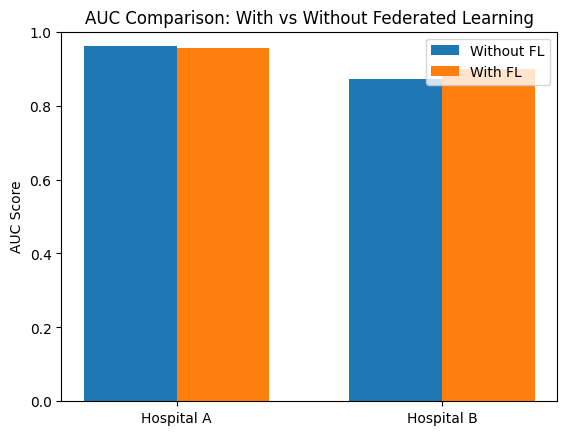

In [25]:
import matplotlib.pyplot as plt                  #AUC COMPARISION
import numpy as np

labels = ['Hospital A', 'Hospital B']

auc_without_FL = [auc_A_local, auc_B_local]
auc_with_FL = [auc_A_FL, auc_B_FL]

x = np.arange(len(labels))   # positions
width = 0.35                 # bar width

plt.figure()

plt.bar(x - width/2, auc_without_FL, width, label='Without FL')
plt.bar(x + width/2, auc_with_FL, width, label='With FL')

plt.xticks(x, labels)
plt.ylabel("AUC Score")
plt.title("AUC Comparison: With vs Without Federated Learning")
plt.legend()

plt.ylim(0,1)

plt.show()

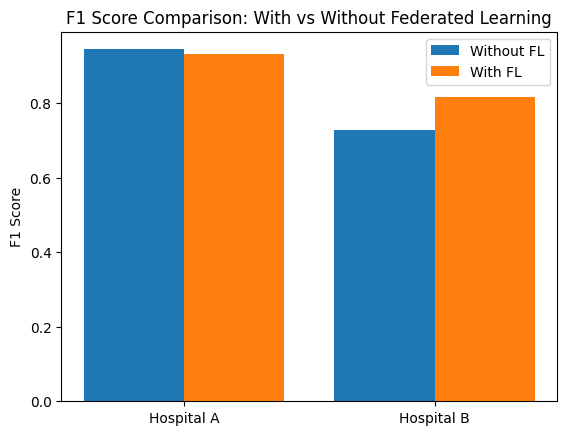

In [26]:
labels = ['Hospital A', 'Hospital B']             #F1 SCORE COMAPARISION

f1_without_FL = [f1_A_local, f1_B_local]
f1_with_FL = [f1_A_FL, f1_B_FL]

x = range(len(labels))

plt.figure()

plt.bar(x, f1_without_FL, width=0.4, label='Without FL')
plt.bar([i+0.4 for i in x], f1_with_FL, width=0.4, label='With FL')

plt.xticks([i+0.2 for i in x], labels)
plt.ylabel("F1 Score")
plt.title("F1 Score Comparison: With vs Without Federated Learning")
plt.legend()

plt.show()

In [ ]:
#ML MODEL COMPARISION (USING RANDOM FOREST)

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score

In [28]:
rf_model_A = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model_A.fit(X_A, y_A)

RandomForestClassifier(random_state=42)

In [29]:
y_pred_A_rf = rf_model_A.predict(X_A)
y_prob_A_rf = rf_model_A.predict_proba(X_A)[:,1]
auc_A_rf = roc_auc_score(y_A, y_prob_A_rf)
f1_A_rf = f1_score(y_A, y_pred_A_rf)

print("Random Forest - Hospital A")
print("AUC:", auc_A_rf)
print("F1 Score:", f1_A_rf)

Random Forest - Hospital A
AUC: 1.0
F1 Score: 1.0


In [30]:
y_pred_B_rf = rf_model_A.predict(X_B)
y_prob_B_rf = rf_model_A.predict_proba(X_B)[:,1]

auc_B_rf = roc_auc_score(y_B, y_prob_B_rf)
f1_B_rf = f1_score(y_B, y_pred_B_rf)

print("\nRandom Forest - Hospital B")
print("AUC:", auc_B_rf)
print("F1 Score:", f1_B_rf)


Random Forest - Hospital B
AUC: 0.8599601248266296
F1 Score: 0.7729468599033816


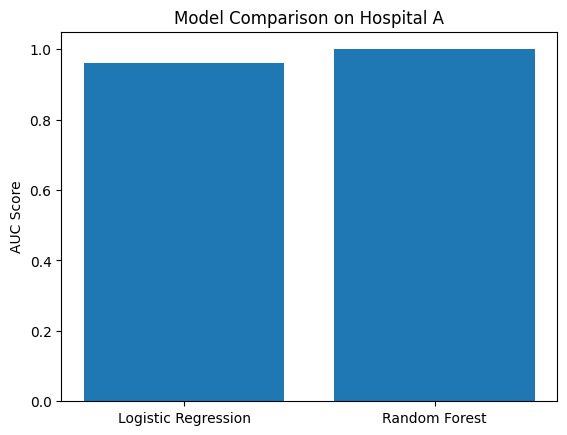

In [31]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Random Forest']
auc_scores = [auc_A_local, auc_A_rf]

plt.figure()
plt.bar(models, auc_scores)
plt.ylabel("AUC Score")
plt.title("Model Comparison on Hospital A")
plt.show()

In [ ]:
#PRIVACY AWARE FL
#Adding Privacy-Aware Federated Learning will make your project much stronger for publication. The idea is simple: when hospitals send model parameters to the server, we add small noise so patient information cannot be reconstructed.

In [32]:
import numpy as np

def add_noise(weights, noise_level=0.01):
    noise = np.random.normal(0, noise_level, weights.shape)
    return weights + noise

In [33]:
# Get local model weights
coef_A = model_A.coef_
coef_B = model_B.coef_

intercept_A = model_A.intercept_
intercept_B = model_B.intercept_

# Add privacy noise
coef_A_private = add_noise(coef_A)
coef_B_private = add_noise(coef_B)

intercept_A_private = add_noise(intercept_A)
intercept_B_private = add_noise(intercept_B)

In [34]:
global_coef = (coef_A_private + coef_B_private) / 2
global_intercept = (intercept_A_private + intercept_B_private) / 2

In [35]:
from sklearn.linear_model import LogisticRegression

global_model = LogisticRegression(max_iter=1000)

global_model.coef_ = global_coef
global_model.intercept_ = global_intercept
global_model.classes_ = model_A.classes_

In [36]:
y_pred_A_FL = global_model.predict(X_A)
y_prob_A_FL = global_model.predict_proba(X_A)[:,1]

auc_A_FL = roc_auc_score(y_A, y_prob_A_FL)
f1_A_FL = f1_score(y_A, y_pred_A_FL)

print("Hospital A WITH Privacy FL")
print("AUC:", auc_A_FL)
print("F1:", f1_A_FL)

Hospital A WITH Privacy FL
AUC: 0.9528535980148883
F1: 0.8794326241134752


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [37]:
import numpy as np
from sklearn.linear_model import LogisticRegression

def add_noise(weights, noise_level=0.01):
    noise = np.random.normal(0, noise_level, weights.shape)
    return weights + noise

# Add noise to model parameters
coef_A_priv = add_noise(model_A.coef_)
coef_B_priv = add_noise(model_B.coef_)

intercept_A_priv = add_noise(model_A.intercept_)
intercept_B_priv = add_noise(model_B.intercept_)

# Aggregate noisy parameters
global_coef_priv = (coef_A_priv + coef_B_priv) / 2
global_intercept_priv = (intercept_A_priv + intercept_B_priv) / 2

# Create privacy-aware FL model
privacy_global_model = LogisticRegression(max_iter=1000)

privacy_global_model.coef_ = global_coef_priv
privacy_global_model.intercept_ = global_intercept_priv
privacy_global_model.classes_ = model_A.classes_

In [38]:
from sklearn.metrics import accuracy_score

# Accuracy for Federated Learning
y_pred_A_FL = global_model.predict(X_A)
accuracy_FL = accuracy_score(y_A, y_pred_A_FL)

# Accuracy for Privacy FL
y_pred_A_privacy = privacy_global_model.predict(X_A)
accuracy_privacy = accuracy_score(y_A, y_pred_A_privacy)

print("FL Accuracy:", accuracy_FL)
print("Privacy FL Accuracy:", accuracy_privacy)

FL Accuracy: 0.8068181818181818
Privacy FL Accuracy: 0.8181818181818182


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


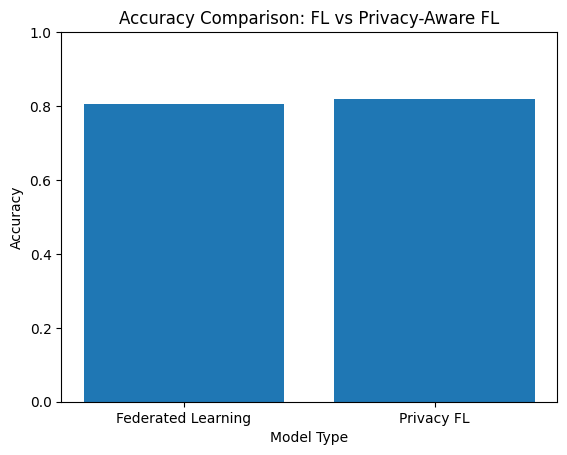

In [39]:
import matplotlib.pyplot as plt

models = ['Federated Learning', 'Privacy FL']
accuracy_scores = [accuracy_FL, accuracy_privacy]

plt.figure()
plt.bar(models, accuracy_scores)

plt.xlabel("Model Type")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison: FL vs Privacy-Aware FL")

plt.ylim(0,1)

plt.show()